In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [94]:
df_train

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [95]:
df_test

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan
...,...,...,...,...
3258,10861,NaN,NaN,EARTHQUAKE SAFETY LOS ANGELES ÛÒ SAFETY FASTE...
3259,10865,NaN,NaN,Storm in RI worse than last hurricane. My city...
3260,10868,NaN,NaN,Green Line derailment in Chicago http://t.co/U...
3261,10874,NaN,NaN,MEG issues Hazardous Weather Outlook (HWO) htt...


In [96]:
df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)

In [97]:
X_train = df_train['text']
X_test = df_train['text']
y = df_train['target']

In [98]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [99]:
token = Tokenizer()

In [100]:
token.fit_on_texts(X_train)

In [101]:
token.word_index

{'t': 1,
 'co': 2,
 'http': 3,
 'the': 4,
 'a': 5,
 'in': 6,
 'to': 7,
 'of': 8,
 'and': 9,
 'i': 10,
 'is': 11,
 'for': 12,
 'on': 13,
 'you': 14,
 'my': 15,
 'with': 16,
 'that': 17,
 'it': 18,
 'at': 19,
 'by': 20,
 'this': 21,
 'from': 22,
 'https': 23,
 'are': 24,
 'be': 25,
 'was': 26,
 'have': 27,
 'like': 28,
 'amp': 29,
 'as': 30,
 'up': 31,
 'me': 32,
 'but': 33,
 'just': 34,
 'so': 35,
 'not': 36,
 'your': 37,
 'out': 38,
 'no': 39,
 'all': 40,
 'after': 41,
 'will': 42,
 'an': 43,
 'has': 44,
 'fire': 45,
 "i'm": 46,
 'when': 47,
 'if': 48,
 'we': 49,
 'get': 50,
 'now': 51,
 'new': 52,
 'via': 53,
 'more': 54,
 '2': 55,
 'about': 56,
 'or': 57,
 'news': 58,
 'people': 59,
 'what': 60,
 'they': 61,
 'one': 62,
 'he': 63,
 'how': 64,
 'been': 65,
 'over': 66,
 'who': 67,
 "it's": 68,
 'into': 69,
 "don't": 70,
 'do': 71,
 'video': 72,
 "'": 73,
 'can': 74,
 'emergency': 75,
 'disaster': 76,
 'there': 77,
 'police': 78,
 'than': 79,
 '3': 80,
 'her': 81,
 'u': 82,
 'would': 8

In [102]:
token.word_counts

OrderedDict([('our', 98),
             ('deeds', 2),
             ('are', 402),
             ('the', 3239),
             ('reason', 20),
             ('of', 1825),
             ('this', 478),
             ('earthquake', 49),
             ('may', 88),
             ('allah', 9),
             ('forgive', 2),
             ('us', 125),
             ('all', 259),
             ('forest', 66),
             ('fire', 245),
             ('near', 55),
             ('la', 22),
             ('ronge', 1),
             ('sask', 1),
             ('canada', 11),
             ('residents', 8),
             ('asked', 9),
             ('to', 1948),
             ("'shelter", 1),
             ('in', 1983),
             ("place'", 1),
             ('being', 89),
             ('notified', 1),
             ('by', 519),
             ('officers', 8),
             ('no', 266),
             ('other', 36),
             ('evacuation', 50),
             ('or', 206),
             ('shelter', 6),
             ('place', 

In [103]:
X_train

0       Our Deeds are the Reason of this #earthquake M...
1                  Forest fire near La Ronge Sask. Canada
2       All residents asked to 'shelter in place' are ...
3       13,000 people receive #wildfires evacuation or...
4       Just got sent this photo from Ruby #Alaska as ...
                              ...                        
7608    Two giant cranes holding a bridge collapse int...
7609    @aria_ahrary @TheTawniest The out of control w...
7610    M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...
7611    Police investigating after an e-bike collided ...
7612    The Latest: More Homes Razed by Northern Calif...
Name: text, Length: 7613, dtype: object

In [104]:
X_train[0]

'Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all'

In [105]:
X_train = token.texts_to_sequences(X_train)
X_test = token.texts_to_sequences(X_test)

In [106]:
max_len = max([len(i) for i in X_train])

In [107]:
max_len

33

In [108]:
from tensorflow.keras.utils import pad_sequences

In [109]:
X_train = pad_sequences(X_train, maxlen = max_len, padding = 'post')

In [110]:
X_train

array([[ 119, 4633,   24, ...,    0,    0,    0],
       [ 189,   45,  229, ...,    0,    0,    0],
       [  40, 1751, 1620, ...,    0,    0,    0],
       ...,
       [2824, 2401,  709, ...,    0,    0,    0],
       [  78, 1145,   41, ...,    0,    0,    0],
       [   4,  209,   54, ...,    0,    0,    0]],
      shape=(7613, 33), dtype=int32)

In [111]:
from sklearn.preprocessing import LabelEncoder

In [112]:
label = LabelEncoder()

In [113]:
y = label.fit_transform(y)

In [114]:
from keras.utils import to_categorical

In [115]:
y = to_categorical(y, num_classes= 2 )

In [116]:
y

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]], shape=(7613, 2))

In [128]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [129]:
from keras import Sequential
from keras.layers import LSTM , Dense, Embedding
from keras.optimizers import Adam
from keras.layers import Dropout

In [130]:
model = Sequential()

model.add(Embedding(len(token.word_index)+1, 32))

model.add(LSTM(8, dropout=0.3, recurrent_dropout=0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

In [131]:
model.compile(optimizer=Adam(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])

In [135]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [136]:
model.fit(
    X_train,
    y,
    validation_split=0.2,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9369 - loss: 0.2227 - val_accuracy: 0.9514 - val_loss: 0.1511
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9598 - loss: 0.1555 - val_accuracy: 0.9311 - val_loss: 0.2195
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9698 - loss: 0.1278 - val_accuracy: 0.9409 - val_loss: 0.1885
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9772 - loss: 0.0987 - val_accuracy: 0.9462 - val_loss: 0.1909


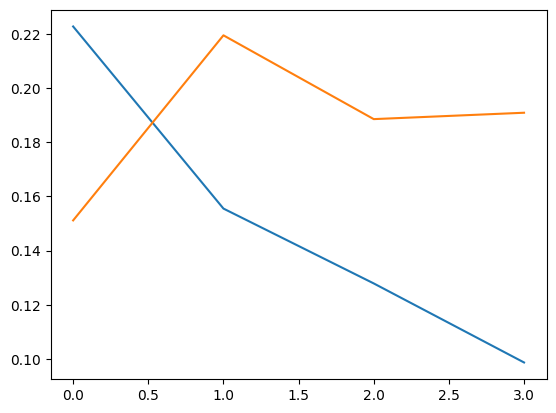

In [137]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

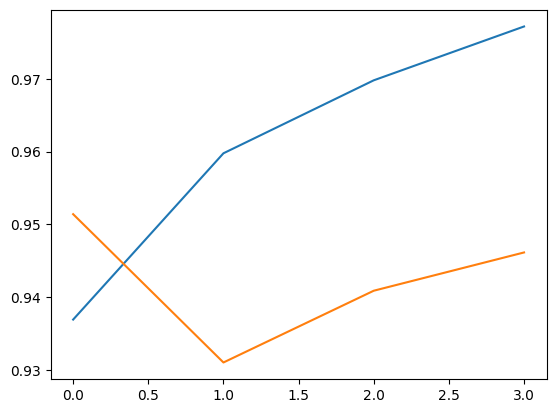

In [138]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [140]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [141]:
y_pred = model.predict(X_test)

238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
df_sub = pd.read_csv('sample_submission.csv')